In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import networkx as nx

# 2D NETWORK

In [ ]:
import subprocess
import numpy as np
from pathlib import Path
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.30 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 15 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

filename = fcn.run_2D_tune_positions(parameters2D)

Configuration already exists: 2D_initial_configurations/2D_neurons_params_PBC_agg_nc15_s0.0800_L3.0_rho250_l0.50_d0.15.txt


Gini coefficient: 0.8082095833333334


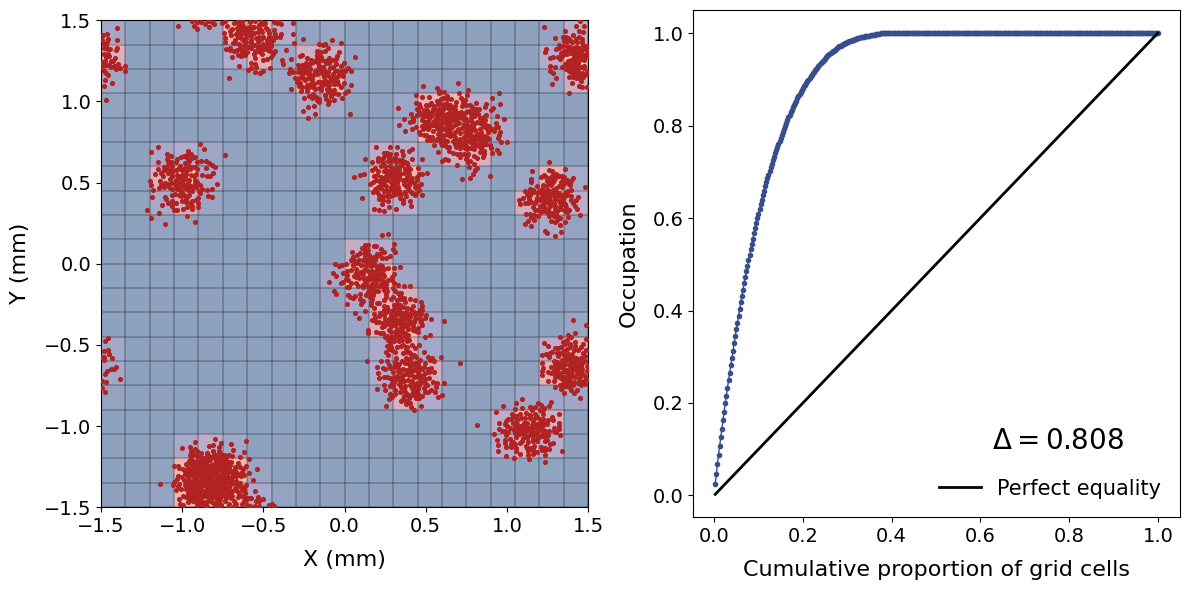

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

fcn.neuron_map_gini2D(filename, parameters2D)

In [42]:
import subprocess
import numpy as np

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

output_filenames = fcn.create_network2D(parameters2D, alphas)

Configuration already exists: 2D_created_networks\2D_adjacency_matrix_PBC_agg_nc15_s0.0800_L3.0_rho250_l0.50_d0.15_a0.200.txt


Loading adjacency matrix from: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc15_s0.0800_L3.0_rho250_l0.50_d0.15_a0.200.txt


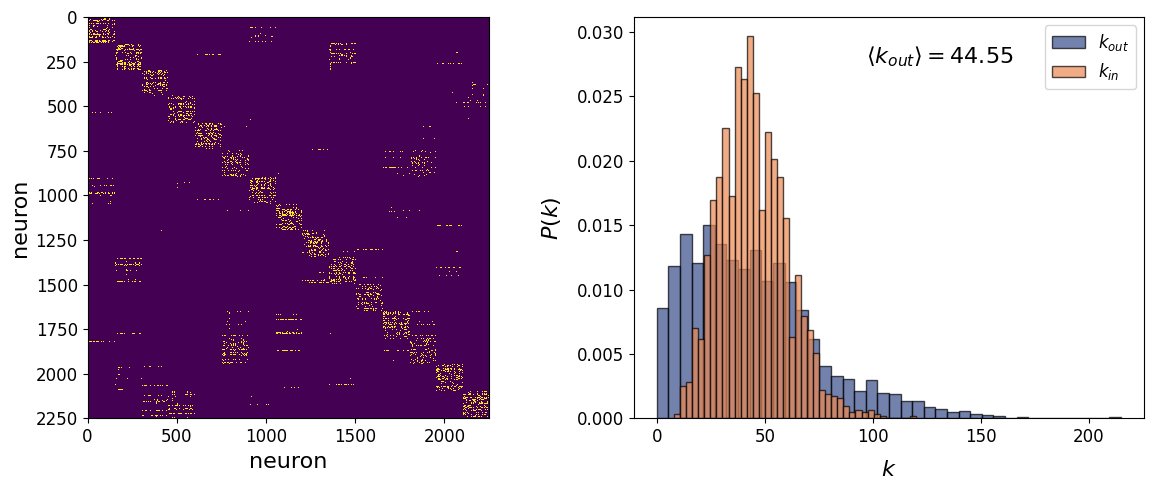

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

filename = output_filenames[0]
print("Loading adjacency matrix from:", filename)

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

A = load_A(filename)

# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# Hacer una matrix de las posibles conexiones que puede hace un axon y luego eliminar de acuerdo a la alpha

In [2]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import subprocess
import numpy as np

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 20 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type

}

number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.40, 50)
Gini_values2D = []

filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = s

        filename = fcn.run_2D_tune_positions(parameters2D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r")

L = parameters2D["L"]
xmin = ymin = -L/2
xmax = ymax = L/2
n_grid = 20

def Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax):
    H, _, _ = np.histogram2d(X, Y, bins=n_grid, range=[[xmin,xmax],[ymin,ymax]])
    bin_sum = H.sum()

    sum_gini = 0.0
    H_flat = H.flatten()
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat))

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini/bin_sum

    bins = np.arange(1, len(H_flat)+1)
    bins = bins/len(H_flat)

    area_between = np.trapezoid(G-bins, bins)
    Gini = 2*area_between
    return Gini

for filename in filenames_Gini:
    X, Y, _, _, _ = fcn.load_neuron_params(filename)
    Gini = Gini_coefficient(X, Y, n_grid, xmin, xmax, ymin, ymax)
    Gini_values2D.append(Gini)

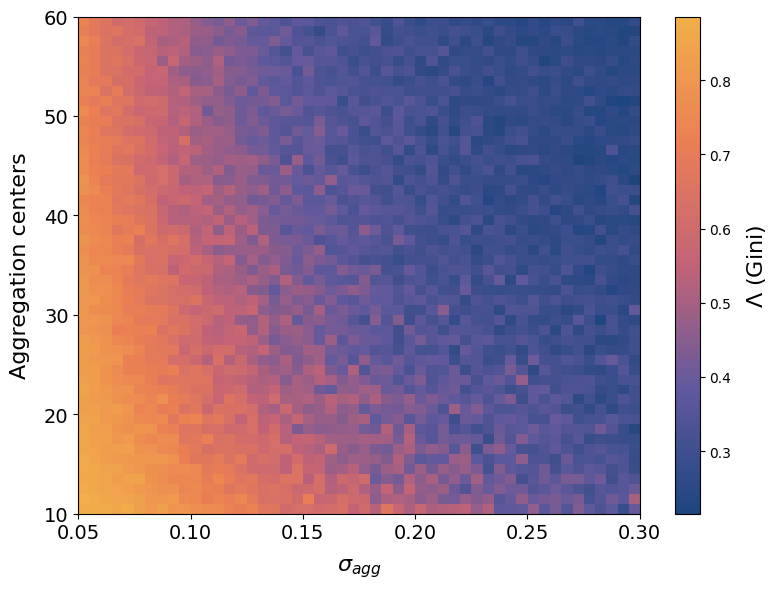

In [7]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

Gini_map = np.array(Gini_values2D).reshape(len(number_of_centers), len(base_sigmas))
file_gini2d = "Gini_things/Gini_2D_values.txt"
with open(file_gini2d, 'w') as f:
    f.write("n_centers\tbase_sigma\tGini\n")
    for i, nc in enumerate(number_of_centers):
        for j, s in enumerate(base_sigmas):
            Gini = Gini_map[i, j]
            f.write(f"{nc}\t{s:.4f}\t{Gini:.6f}\n")

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    # interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

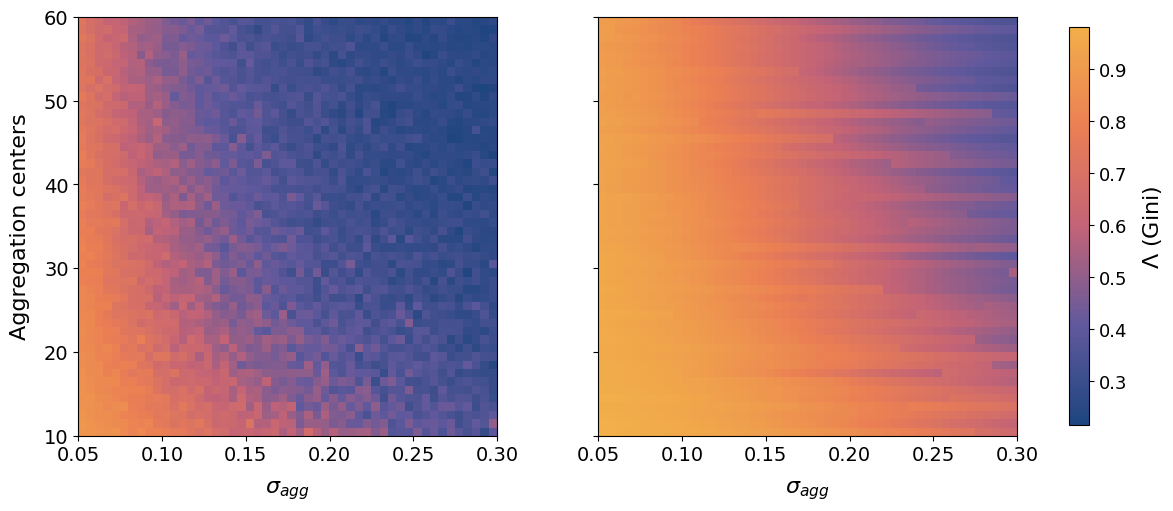

In [14]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt
import numpy as np

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# --- mapa 3D ---
gini3dfile = "Gini_things/Gini_3D_values.txt"
gini_data = np.loadtxt(gini3dfile, skiprows=1)

number_of_centers = np.unique(gini_data[:, 0])
base_sigmas = np.unique(gini_data[:, 1])
Gini_values = gini_data[:, 2]

Gini_map_3D = np.array(Gini_values).reshape(len(number_of_centers), len(base_sigmas))

# --- mapa 2D ---
gini2dfile = "Gini_things/Gini_2D_values.txt"
gini_data2D = np.loadtxt(gini2dfile, skiprows=1)
Gini_values2D = gini_data2D[:, 2]
Gini_map_2D = np.array(Gini_values2D).reshape(len(number_of_centers), len(base_sigmas))

# --- escala común ---
vmin = min(Gini_map_3D.min(), Gini_map_2D.min())
vmax = max(Gini_map_3D.max(), Gini_map_2D.max())

# =======================
# Figura
# =======================
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)

im2D = axs[0].imshow(
    Gini_map_2D,
    origin='lower',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    vmin=vmin,
    vmax=vmax,
    aspect='auto'
)

im3D = axs[1].imshow(
    Gini_map_3D,
    origin='lower',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    vmin=vmin,
    vmax=vmax,
    aspect='auto'
)

# Hacer ambos paneles cuadrados
axs[0].set_box_aspect(1)
axs[1].set_box_aspect(1)

# Etiquetas
axs[0].set_xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad=10)
axs[1].set_xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad=10)
axs[0].set_ylabel('Aggregation centers', fontsize=16, labelpad=10)

axs[0].tick_params(labelsize=14)
axs[1].tick_params(labelsize=14)

# Un solo colorbar compartido a la derecha
cbar = fig.colorbar(im3D, ax=axs, location='right', shrink=0.95, pad=0.03)
cbar.set_label(r'$\Lambda$ (Gini)', fontsize=16, labelpad=10)
cbar.ax.tick_params(labelsize=13)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
from IPython.display import HTML, display

# ============================================================
# ESTILO GLOBAL
# ============================================================
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# ============================================================
# PARÁMETROS DEL SISTEMA
# ============================================================
L = 3.0
rho = 250
N = int(rho * L**2)
soma_diameter = 0.015
d_mean = 0.15
d_sigma = 0.02
l_mean = 0.87
segment_length = 0.01
sigma_axon_angle = 0.1

agg = 0
n_centers = 10
base_sigma = 0.05

BC_type = "SW"
alpha = 0.2

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

# ============================================================
# AJUSTES DE ENTRADA / SALIDA
# ============================================================
NEURONS_FILE = "2D_initial_configurations/2D_neurons_params_SW_random_L3.0_rho250_l1.00_d0.15.txt"
SEGMENTS_FILE = "2D_axon_simulation/2D_axon_positions_SW_random_L3.0_rho250_l1.00_d0.15_a0.200.txt"

N_SHOW = 100
RANDOM_SEED = 42

SHOW_DENDRITES = True
SHOW_SOMAS = True

SAVE_GIF = True
OUTPUT_GIF = "axon_growth_corrected.gif"

FPS = 10
INTERVAL_MS = 90

LINEWIDTH = 1.4
SOMA_LW = 1.0
DENDRITE_LW = 1.2

FORCE_DOMAIN_FROM_L = True
AXIS_PAD = 0.12   # margen extra alrededor del dominio

# ============================================================
# 1) LEER FICHERO DE PARÁMETROS DE NEURONAS
# ============================================================
def load_neuron_params(filepath):
    meta = {}
    header_line_idx = None

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        s = line.strip()

        if not s:
            continue

        if s.startswith("X") and "Y" in s and "Soma_Diameter" in s:
            header_line_idx = i
            break

        if "=" in s:
            key, value = s.split("=", 1)
            key = key.strip()
            value = value.strip()

            try:
                if "." in value or "e" in value.lower():
                    value_cast = float(value)
                else:
                    value_cast = int(value)
                meta[key] = value_cast
            except ValueError:
                meta[key] = value

    if header_line_idx is None:
        raise ValueError("No se encontró la cabecera de la tabla de neuronas.")

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=header_line_idx,
        engine="python"
    )

    df = df.reset_index().rename(columns={"index": "Neuron_Row_Index"})
    return meta, df

# ============================================================
# 2) LEER FICHERO DE SEGMENTOS DE AXONES
# ============================================================
def load_axon_segments(filepath):
    df = pd.read_csv(filepath, sep=r"\s+", engine="python")

    expected = [
        "Neuron_Index", "Segment_Index", "Subsegment_Index",
        "Start_X", "Start_Y", "End_X", "End_Y"
    ]
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el fichero de segmentos: {missing}")

    df = df.sort_values(
        ["Neuron_Index", "Segment_Index", "Subsegment_Index"]
    ).reset_index(drop=True)

    return df

# ============================================================
# 3) MAPPING AXÓN -> SOMA POR PROXIMIDAD
# ============================================================
def build_neuron_mapping_nearest_only(neurons_df, axon_df):
    first_seg = (
        axon_df.sort_values(["Neuron_Index", "Segment_Index", "Subsegment_Index"])
               .groupby("Neuron_Index", as_index=False)
               .first()
    )

    soma_xy = neurons_df[["X", "Y"]].to_numpy()
    soma_diam = neurons_df["Soma_Diameter"].to_numpy()

    mapping = {}
    rows_out = []

    for _, row in first_seg.iterrows():
        axon_neuron_idx = int(row["Neuron_Index"])
        p = np.array([row["Start_X"], row["Start_Y"]], dtype=float)

        dists = np.sqrt(((soma_xy - p) ** 2).sum(axis=1))
        best_idx = int(np.argmin(dists))

        mapping[axon_neuron_idx] = best_idx

        rows_out.append({
            "Axon_Neuron_Index": axon_neuron_idx,
            "Neuron_Row": best_idx,
            "Start_X": row["Start_X"],
            "Start_Y": row["Start_Y"],
            "Soma_X": neurons_df.iloc[best_idx]["X"],
            "Soma_Y": neurons_df.iloc[best_idx]["Y"],
            "Distance": dists[best_idx],
            "Soma_Radius": soma_diam[best_idx] / 2
        })

    mapping_df = pd.DataFrame(rows_out)
    return mapping, mapping_df

# ============================================================
# 4) PREPARAR ESTRUCTURA POR SEGMENTOS
# ============================================================
def build_segment_dict(axon_df, selected_neurons):
    seg_df = axon_df[axon_df["Neuron_Index"].isin(selected_neurons)].copy()

    segment_dict = {}
    max_segment_idx = 0

    grouped = seg_df.groupby(["Neuron_Index", "Segment_Index"], sort=True)

    for (neuron_idx, segment_idx), g in grouped:
        g = g.sort_values("Subsegment_Index")

        pieces = []
        for _, row in g.iterrows():
            pieces.append([
                (float(row["Start_X"]), float(row["Start_Y"])),
                (float(row["End_X"]), float(row["End_Y"]))
            ])

        segment_dict[(int(neuron_idx), int(segment_idx))] = pieces
        max_segment_idx = max(max_segment_idx, int(segment_idx))

    return segment_dict, max_segment_idx

# ============================================================
# 5) CARGA DE DATOS
# ============================================================
meta, neurons_df = load_neuron_params(NEURONS_FILE)
axon_df = load_axon_segments(SEGMENTS_FILE)

if FORCE_DOMAIN_FROM_L and "L" in meta:
    Lbox = float(meta["L"])
    xmin, xmax = -Lbox / 2 - AXIS_PAD, Lbox / 2 + AXIS_PAD
    ymin, ymax = -Lbox / 2 - AXIS_PAD, Lbox / 2 + AXIS_PAD
else:
    pad = 0.05
    xmin = min(neurons_df["X"].min(), axon_df[["Start_X", "End_X"]].min().min()) - pad
    xmax = max(neurons_df["X"].max(), axon_df[["Start_X", "End_X"]].max().max()) + pad
    ymin = min(neurons_df["Y"].min(), axon_df[["Start_Y", "End_Y"]].min().min()) - pad
    ymax = max(neurons_df["Y"].max(), axon_df[["Start_Y", "End_Y"]].max().max()) + pad

# ============================================================
# 6) CONSTRUIR MAPPING CORRECTO
# ============================================================
mapping, mapping_df = build_neuron_mapping_nearest_only(neurons_df, axon_df)

print("\nResumen distancias axón-soma más cercano:")
print(mapping_df["Distance"].describe())

# ============================================================
# 7) ELEGIR NEURONAS
# ============================================================
available_neurons = np.array(sorted(mapping.keys()))
rng = np.random.default_rng(RANDOM_SEED)

if N_SHOW > len(available_neurons):
    N_SHOW = len(available_neurons)

selected_neurons = np.sort(
    rng.choice(available_neurons, size=N_SHOW, replace=False)
)

mapped_rows = [mapping[n] for n in selected_neurons]
neurons_sel = neurons_df.iloc[mapped_rows].copy().reset_index(drop=True)
neurons_sel["Axon_Neuron_Index"] = selected_neurons

# ============================================================
# 8) PREPARAR SEGMENTOS
# ============================================================
segment_dict, max_segment_idx = build_segment_dict(axon_df, selected_neurons)

# ============================================================
# 9) FIGURA
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
# ax.set_title("Crecimiento axonal simultáneo")

ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.3)

# caja del dominio real
if "L" in meta:
    Lreal = float(meta["L"])
    xr0, xr1 = -Lreal / 2, Lreal / 2
    yr0, yr1 = -Lreal / 2, Lreal / 2
    ax.plot(
        [xr0, xr1, xr1, xr0, xr0],
        [yr0, yr0, yr1, yr1, yr0],
        lw=1.,
        ls ="--",
        color="gray",
        alpha=0.3,
        zorder=0
    )

# líneas de axones
line_collection = LineCollection(
    [],
    linewidths=LINEWIDTH,
    colors="tab:blue",
    alpha=0.9
)
line_collection.set_zorder(1)
ax.add_collection(line_collection)

# dendritas
if SHOW_DENDRITES:
    for _, row in neurons_sel.iterrows():
        dend = Circle(
            (row["X"], row["Y"]),
            radius=row["Dendrite_Diameter"] / 2.0,
            fill=True,
            lw=DENDRITE_LW,
            facecolor = "lightgray",
            edgecolor="gray",
            alpha=0.45
        )
        dend.set_zorder(2)
        ax.add_patch(dend)

# somas
if SHOW_SOMAS:
    for _, row in neurons_sel.iterrows():
        soma = Circle(
            (row["X"], row["Y"]),
            radius=row["Soma_Diameter"] / 2.0,
            facecolor="tab:blue",
            edgecolor="none",
            alpha=0.9
        )
        soma.set_zorder(3)
        ax.add_patch(soma)

# texto
time_text = ax.text(
    0.5, 1.02, "",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=16
)

# ============================================================
# 10) PRECOMPUTAR CRECIMIENTO ACUMULADO
# ============================================================
frames_segments = []
current_segments = []

for k in range(max_segment_idx + 1):
    new_pieces = []

    for neuron_idx in selected_neurons:
        key = (int(neuron_idx), k)
        if key in segment_dict:
            new_pieces.extend(segment_dict[key])

    current_segments.extend(new_pieces)
    frames_segments.append(list(current_segments))

# ============================================================
# 11) ANIMACIÓN
# ============================================================
def init():
    line_collection.set_segments([])
    # time_text.set_text(f"Crecimiento axonal simultáneo | k = 0 ")
    return line_collection, time_text

def update(frame):
    segs = frames_segments[frame]
    line_collection.set_segments(segs)
    # time_text.set_text(
    #     # f"Crecimiento axonal simultáneo | k = {frame}"
    # )
    return line_collection, time_text

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames_segments),
    init_func=init,
    interval=INTERVAL_MS,
    blit=True
)

plt.tight_layout()

# ============================================================
# 12) GUARDAR GIF OPCIONAL
# ============================================================
if SAVE_GIF:
    writer = PillowWriter(fps=FPS)
    anim.save(OUTPUT_GIF, writer=writer)
    print(f"\nGIF guardado en: {OUTPUT_GIF}")

# ============================================================
# 13) MOSTRAR VISOR INTERACTIVO TIPO NOTEBOOK
# ============================================================
plt.close(fig)
display(HTML(anim.to_jshtml()))

In [ ]:
def build_neuron_mapping_nearest_only(neurons_df, axon_df):
    first_seg = (
        axon_df.sort_values(["Neuron_Index", "Segment_Index", "Subsegment_Index"])
               .groupby("Neuron_Index", as_index=False)
               .first()
    )

    soma_xy = neurons_df[["X", "Y"]].to_numpy()
    soma_diam = neurons_df["Soma_Diameter"].to_numpy()

    mapping = {}
    rows_out = []

    for _, row in first_seg.iterrows():
        axon_neuron_idx = int(row["Neuron_Index"])
        p = np.array([row["Start_X"], row["Start_Y"]])

        dists = np.sqrt(((soma_xy - p) ** 2).sum(axis=1))
        best_idx = int(np.argmin(dists))

        mapping[axon_neuron_idx] = best_idx

        rows_out.append({
            "Axon_Neuron_Index": axon_neuron_idx,
            "Neuron_Row": best_idx,
            "Start_X": row["Start_X"],
            "Start_Y": row["Start_Y"],
            "Soma_X": neurons_df.iloc[best_idx]["X"],
            "Soma_Y": neurons_df.iloc[best_idx]["Y"],
            "Distance": dists[best_idx],
            "Soma_Radius": soma_diam[best_idx] / 2
        })

    mapping_df = pd.DataFrame(rows_out)
    return mapping, mapping_df

mapping, mapping_df = build_neuron_mapping_nearest_only(neurons_df, axon_df)
print(mapping_df["Distance"].describe())

# -- 2D DYNAMICS --

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# -------- PARAMETERS --------

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 15 # Number of centers for the aggregation of neurons
base_sigma = 0.08 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

filename_params = fcn.run_2D_tune_positions(parameters2D)
path = fcn.create_network2D(parameters2D, alphas)[0]

# -------- USO --------

A = fcn.load_A(path)
C, k, E = fcn.connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)

# Visualización
fcn.neuron_map_adj2D(filename_params, path, parameters2D)

# -------- Pesos --------

N = A.shape[0]

Ne = int(N*0.8)
Ni = int(N*0.2)
N = Ne + Ni

SIM_TIME = 5000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

MAX_EXC_WEIGTH = 8
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

S = A * W
NOISE_MAX = 3

In [ ]:
v = -65*np.ones((N, 1))
u = b * v

firings_t = [] # tiempos de disparo
firings_i = [] # índices de neuronas que disparan (0..N-1)

for t in range(1, SIM_TIME+1):
    I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

    fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

    if fired.size > 0:
        firings_t.append(np.full(fired.shape, t, dtype=int))
        firings_i.append(fired.copy())

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        # I = I + sum(S(:, fired), 2)
        # En numpy: sumamos columnas "fired" y nos queda vector Nx1
        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    # Integración (paso 0.5 ms x2)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    u = u + a*(b*v - u)

# Convertir lista de arrays a arrays.
#  planos
if len(firings_t) > 0:
    firings_t = np.concatenate(firings_t)
    firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
else:
    firings_t = np.array([], dtype=int)
    firings_i = np.array([], dtype=int)

print("Total spikes:", len(firings_t))

In [ ]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

plt.figure(figsize=(6, 5))
plt.scatter(firings_t, firings_i, s=7, color=sunset2(0.1))
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron', fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(200, 300)
plt.show()

In [ ]:
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

W = 25  # ms

GNA, active_neurons_count = fcn.compute_GNA_from_raster(
    firings_t=firings_t,
    firings_i=firings_i,
    N=N,
    SIM_TIME=SIM_TIME,
    W=W,
    indices_are_1_based=True   # en tu código hiciste +1 al final
)

peaks, properties = find_peaks(
    GNA,
    height=0.1,      # altura mínima del pico en %
    distance=20    # separación mínima entre picos (ms)
)

peak_heights = properties["peak_heights"]
mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0

print("Número de picos detectados:", len(peaks))
print("Alturas de los picos (%):", peak_heights)
print("Altura media de los picos (%):", mean_peak_height)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, SIM_TIME + 1), GNA, lw=1.5, color=sunset2(0.1))
plt.scatter(peaks + 1, GNA[peaks], s=35, color="red", zorder=3)

plt.xlabel("Tiempo (ms)", fontsize=16)
plt.ylabel(f"GNA\n(W =  {W} ms)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.xlim(0, 2000)
plt.show()

## -- 2D GNA map --

In [5]:
import subprocess
import numpy as np
import os
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 1.2 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 25 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 25
base_sigmas = np.linspace(0.05, 0.4, 50)

# Handle both a single int and an iterable of centers
n_centers_iter = np.atleast_1d(number_of_centers).astype(int)


for base_sigma in base_sigmas:
    for nc in n_centers_iter:
        parameters2D["n_centers"] = nc
        parameters2D["base_sigma"] = base_sigma

        filename = fcn.run_2D_tune_positions(parameters2D, show_prints=False)
        print(f"Configuration created for n_centers={nc}, base_sigma={base_sigma:.4f}", end="\r")

filenames_params = [
    f"2D_initial_configurations/2D_neurons_params_{BC_type}_agg_nc{nc}_s{s:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
    for nc in n_centers_iter
    for s in base_sigmas
]
#Check if files exist
for filename in filenames_params:
    if not os.path.isfile(filename):
        print(f"File not found: {filename}")

In [6]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 1.2 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 25
parameters2D["n_centers"] = number_of_centers
base_sigmas = np.linspace(0.05, 0.40, 50)   
print('Length of base_sigmas:', len(base_sigmas))
print(base_sigmas)

alphas = [0.2]

for base_sigma in base_sigmas:
    parameters2D["base_sigma"] = base_sigma
    filename = fcn.create_network2D(parameters2D, alphas, show_prints=False)[0]
    print(filename)
    print(f"Created network for n_centers={number_of_centers}, {parameters2D['base_sigma']:.4f}", end="\r")

Length of base_sigmas: 50
[0.05       0.05714286 0.06428571 0.07142857 0.07857143 0.08571429
 0.09285714 0.1        0.10714286 0.11428571 0.12142857 0.12857143
 0.13571429 0.14285714 0.15       0.15714286 0.16428571 0.17142857
 0.17857143 0.18571429 0.19285714 0.2        0.20714286 0.21428571
 0.22142857 0.22857143 0.23571429 0.24285714 0.25       0.25714286
 0.26428571 0.27142857 0.27857143 0.28571429 0.29285714 0.3
 0.30714286 0.31428571 0.32142857 0.32857143 0.33571429 0.34285714
 0.35       0.35714286 0.36428571 0.37142857 0.37857143 0.38571429
 0.39285714 0.4       ]
2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0500_L3.0_rho250_l1.20_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0571_L3.0_rho250_l1.20_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0643_L3.0_rho250_l1.20_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matrix_PBC_agg_nc25_s0.0714_L3.0_rho250_l1.20_d0.15_a0.200.txt
2D_created_networks/2D_adjacency_matr

In [5]:
import numpy as np

MAX_EXC_WEIGTH = np.linspace(2, 20, 50)
delta_MEW = MAX_EXC_WEIGTH[1] - MAX_EXC_WEIGTH[0]
print("Delta MEW:", delta_MEW)

Delta MEW: 0.36734693877551017


In [7]:
import importlib
import numpy as np
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 1.2 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)
BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)


parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

nc = 25
parameters2D["n_centers"] = nc
base_sigmas = np.linspace(0.05, 0.40, 50)   
print('Length of base_sigmas:', len(base_sigmas))

# MAX_EXC_WEIGTH = np.linspace(10, 20, 50)  # Puedes ajustar esto según tus necesidades
import numpy as np

MAX_EXC_WEIGTH = np.linspace(2, 20, 50)
delta_MEW = MAX_EXC_WEIGTH[1] - MAX_EXC_WEIGTH[0]
print("Delta MEW:", delta_MEW)
MAX_EXC_WEIGTH = np.arange(10, 20, delta_MEW)  # Asegúrate de que el paso sea igual a delta_MEW para mantener la consistencia
print('Length of MAX_EXC_WEIGTH:', len(MAX_EXC_WEIGTH))
MAX_INH_WEIGTH = 0.5

alpha = 0.2

output_filename = f'maps_results/2D_colormap_Gini_Exc_GNA_nc{nc}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.3f}_repeat10_20.txt'
with open(output_filename, 'w') as f:
     f.write("Gini\tMAX_EXC_WEIGTH\tmean_peaks_height\tstd_peaks_height\n")

i = 0
for base_sigma in base_sigmas:
    parameters2D["base_sigma"] = base_sigma
    path_params = f"2D_initial_configurations/2D_neurons_params_{BC_type}_agg_nc{parameters2D['n_centers']}_s{parameters2D['base_sigma']:.4f}_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}.txt"
    X, Y, _, _, _ = fcn.load_neuron_params(path_params)
    Gini = fcn.Gini_coefficient(X, Y, n_grid = 20, xmin = -parameters2D['L']/2, xmax = parameters2D['L']/2, ymin = -parameters2D['L']/2, ymax = parameters2D['L']/2)
    path_adj = f"2D_created_networks/2D_adjacency_matrix_{BC_type}_agg_nc{parameters2D['n_centers']}_s{parameters2D['base_sigma']:.4f}_L{parameters2D['L']:.1f}_rho{parameters2D['rho']:.0f}_l{parameters2D['l_mean']:.2f}_d{parameters2D['d_mean']:.2f}_a{alpha:.3f}.txt"
    A = fcn.load_A(path_adj)
    N = A.shape[0]

    Ne = int(N*0.8)
    Ni = int(N*0.2)
    N = Ne + Ni

    SIM_TIME = 5000

    # 2) Izhikevich parameters (con variabilidad)
    re = np.random.rand(Ne, 1)
    ri = np.random.rand(Ni, 1)

    a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
    b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
    c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
    d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

    for max_exc in MAX_EXC_WEIGTH:

        W = np.hstack([
            max_exc*np.random.rand(N, Ne),
            -MAX_INH_WEIGTH*np.random.rand(N, Ni)
        ])

        S = A * W
        NOISE_MAX = 3

        v = -65*np.ones((N, 1))
        u = b * v

        firings_t = [] # tiempos de disparo
        firings_i = [] # índices de neuronas que disparan (0..N-1)

        for t in range(1, SIM_TIME+1):
            I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

            fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

            if fired.size > 0:
                firings_t.append(np.full(fired.shape, t, dtype=int))
                firings_i.append(fired.copy())

                v[fired] = c[fired]
                u[fired] = u[fired] + d[fired]

                # I = I + sum(S(:, fired), 2)
                # En numpy: sumamos columnas "fired" y nos queda vector Nx1
                I = I + np.sum(S[:, fired], axis=1, keepdims=True)

            # Integración (paso 0.5 ms x2)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            u = u + a*(b*v - u)

        # Convertir lista de arrays a arrays.
        #  planos
        if len(firings_t) > 0:
            firings_t = np.concatenate(firings_t)
            firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
        else:
            firings_t = np.array([], dtype=int)
            firings_i = np.array([], dtype=int)
        
        print(f"Simulated network for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, Gini={Gini:.4f}, total spikes={len(firings_t)}")

        GNA, active_neurons_count = fcn.compute_GNA_from_raster(
            firings_t=firings_t,
            firings_i=firings_i,
            N=N,
            SIM_TIME=SIM_TIME,
            W=25,
            indices_are_1_based=True
        )
        peaks, properties = find_peaks(
            GNA,
            height=0.2,      # altura mínima del pico en %
            distance=20    # separación mínima entre picos (ms)
        )
        peak_heights = properties["peak_heights"]
        mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0
        print(f"Detected {len(peaks)} peaks in GNA for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, mean_peak_height={mean_peak_height:.4f}%")
        std_peak_height = np.std(peak_heights) if len(peak_heights) > 0 else 0.0

        with open(output_filename, 'a') as f:
            f.write(f"{Gini}\t{max_exc}\t{mean_peak_height}\t{std_peak_height}\n")
        
    i += 1

Length of base_sigmas: 50
Delta MEW: 0.36734693877551017
Length of MAX_EXC_WEIGTH: 28
Simulated network for base_sigma=0.0500, max_exc=10.00, Gini=0.8347, total spikes=1517390
Detected 40 peaks in GNA for base_sigma=0.0500, max_exc=10.00, mean_peak_height=0.9354%
Simulated network for base_sigma=0.0500, max_exc=10.37, Gini=0.8347, total spikes=1571034
Detected 40 peaks in GNA for base_sigma=0.0500, max_exc=10.37, mean_peak_height=0.9297%
Simulated network for base_sigma=0.0500, max_exc=10.73, Gini=0.8347, total spikes=1833641
Detected 45 peaks in GNA for base_sigma=0.0500, max_exc=10.73, mean_peak_height=0.9236%
Simulated network for base_sigma=0.0500, max_exc=11.10, Gini=0.8347, total spikes=1970829
Detected 46 peaks in GNA for base_sigma=0.0500, max_exc=11.10, mean_peak_height=0.9360%
Simulated network for base_sigma=0.0500, max_exc=11.47, Gini=0.8347, total spikes=2096225
Detected 47 peaks in GNA for base_sigma=0.0500, max_exc=11.47, mean_peak_height=0.9365%
Simulated network for ba

C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: overflow encountered in multiply
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: invalid value encountered in add
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)


Simulated network for base_sigma=0.0500, max_exc=16.61, Gini=0.8347, total spikes=3701884
Detected 56 peaks in GNA for base_sigma=0.0500, max_exc=16.61, mean_peak_height=0.9097%


C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: overflow encountered in multiply
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: invalid value encountered in add
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)


Simulated network for base_sigma=0.0500, max_exc=16.98, Gini=0.8347, total spikes=3791495
Detected 62 peaks in GNA for base_sigma=0.0500, max_exc=16.98, mean_peak_height=0.8543%
Simulated network for base_sigma=0.0500, max_exc=17.35, Gini=0.8347, total spikes=3810950
Detected 60 peaks in GNA for base_sigma=0.0500, max_exc=17.35, mean_peak_height=0.9138%
Simulated network for base_sigma=0.0500, max_exc=17.71, Gini=0.8347, total spikes=3948304
Detected 75 peaks in GNA for base_sigma=0.0500, max_exc=17.71, mean_peak_height=0.7519%
Simulated network for base_sigma=0.0500, max_exc=18.08, Gini=0.8347, total spikes=4073660
Detected 101 peaks in GNA for base_sigma=0.0500, max_exc=18.08, mean_peak_height=0.6125%
Simulated network for base_sigma=0.0500, max_exc=18.45, Gini=0.8347, total spikes=4117299
Detected 102 peaks in GNA for base_sigma=0.0500, max_exc=18.45, mean_peak_height=0.6267%
Simulated network for base_sigma=0.0500, max_exc=18.82, Gini=0.8347, total spikes=4229178
Detected 87 peaks 

...

Simulated network for base_sigma=0.3643, max_exc=14.78, Gini=0.3269, total spikes=975839
Detected 25 peaks in GNA for base_sigma=0.3643, max_exc=14.78, mean_peak_height=0.9983%
Simulated network for base_sigma=0.3643, max_exc=15.14, Gini=0.3269, total spikes=1210272
Detected 38 peaks in GNA for base_sigma=0.3643, max_exc=15.14, mean_peak_height=0.8327%
Simulated network for base_sigma=0.3643, max_exc=15.51, Gini=0.3269, total spikes=1249332
Detected 31 peaks in GNA for base_sigma=0.3643, max_exc=15.51, mean_peak_height=0.9902%
Simulated network for base_sigma=0.3643, max_exc=15.88, Gini=0.3269, total spikes=1497572
Detected 35 peaks in GNA for base_sigma=0.3643, max_exc=15.88, mean_peak_height=0.9985%
Simulated network for base_sigma=0.3643, max_exc=16.24, Gini=0.3269, total spikes=1582196
Detected 36 peaks in GNA for base_sigma=0.3643, max_exc=16.24, mean_peak_height=0.9994%
Simulated network for base_sigma=0.3643, max_exc=16.61, Gini=0.3269, total spikes=1702419
Detected 37 peaks in 

C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: overflow encountered in multiply
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: invalid value encountered in add
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)


Simulated network for base_sigma=0.3714, max_exc=13.31, Gini=0.3144, total spikes=705033
Detected 22 peaks in GNA for base_sigma=0.3714, max_exc=13.31, mean_peak_height=0.9980%
Simulated network for base_sigma=0.3714, max_exc=13.67, Gini=0.3144, total spikes=1005353
Detected 30 peaks in GNA for base_sigma=0.3714, max_exc=13.67, mean_peak_height=0.9987%
Simulated network for base_sigma=0.3714, max_exc=14.04, Gini=0.3144, total spikes=1104294
Detected 32 peaks in GNA for base_sigma=0.3714, max_exc=14.04, mean_peak_height=0.9993%
Simulated network for base_sigma=0.3714, max_exc=14.41, Gini=0.3144, total spikes=1143414
Detected 32 peaks in GNA for base_sigma=0.3714, max_exc=14.41, mean_peak_height=0.9980%
Simulated network for base_sigma=0.3714, max_exc=14.78, Gini=0.3144, total spikes=1212303
Detected 33 peaks in GNA for base_sigma=0.3714, max_exc=14.78, mean_peak_height=0.9987%
Simulated network for base_sigma=0.3714, max_exc=15.14, Gini=0.3144, total spikes=1309243
Detected 35 peaks in 

C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: overflow encountered in multiply
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7672\2452723085.py:118: RuntimeWarning: invalid value encountered in add
  v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)


Simulated network for base_sigma=0.3857, max_exc=14.41, Gini=0.2871, total spikes=907785
Detected 25 peaks in GNA for base_sigma=0.3857, max_exc=14.41, mean_peak_height=0.9996%
Simulated network for base_sigma=0.3857, max_exc=14.78, Gini=0.2871, total spikes=1048681
Detected 28 peaks in GNA for base_sigma=0.3857, max_exc=14.78, mean_peak_height=0.9989%
Simulated network for base_sigma=0.3857, max_exc=15.14, Gini=0.2871, total spikes=1205540
Detected 31 peaks in GNA for base_sigma=0.3857, max_exc=15.14, mean_peak_height=0.9992%
Simulated network for base_sigma=0.3857, max_exc=15.51, Gini=0.2871, total spikes=1273677
Detected 32 peaks in GNA for base_sigma=0.3857, max_exc=15.51, mean_peak_height=0.9989%
Simulated network for base_sigma=0.3857, max_exc=15.88, Gini=0.2871, total spikes=1316407
Detected 32 peaks in GNA for base_sigma=0.3857, max_exc=15.88, mean_peak_height=0.9988%
Simulated network for base_sigma=0.3857, max_exc=16.24, Gini=0.2871, total spikes=1426476
Detected 34 peaks in 

In [ ]:
import numpy as np

# Cargar datos
filename = "maps_results/2D_colormap_Gini_Exc_GNA_nc25_L3.0_rho250_l0.50_d0.15_a0.200.txt"
data = np.loadtxt(filename, skiprows=1)

# Ordenar por la primera columna (Gini)
data_sorted = data[data[:, 0].argsort()]

# Guardar archivo ordenado
output_filename = "maps_results/sorted_by_gini.txt"

# Guardamos con cabecera
header = "Gini\tMAX_EXC_WEIGHT\tmean_peaks_height\tstd_peaks_height"
np.savetxt(
    output_filename,
    data_sorted,
    delimiter="\t",      
    header=header,
    fmt="%.10f",
    comments=""
)

Index(['Gini', 'MAX_EXC_WEIGHT', 'mean_peaks_height', 'std_peaks_height'], dtype='object')
MAX_EXC_WEIGHT  Gini    
2.0             0.275812    1
                0.287104    1
                0.292467    1
                0.309115    1
                0.314396    1
                           ..
20.0            0.751305    1
                0.774791    1
                0.801122    1
                0.807606    1
                0.834731    1
Length: 2500, dtype: int64


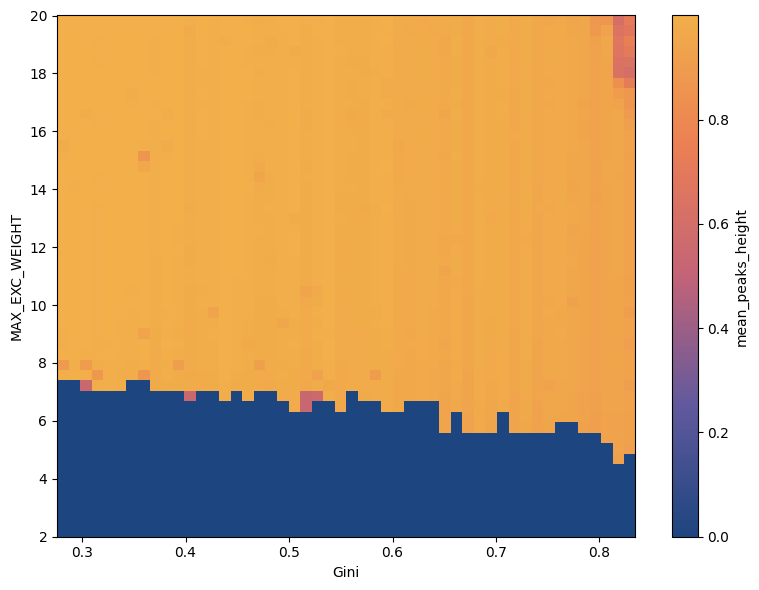

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pypalettes import load_cmap

sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# Cargar el txt
df = pd.read_csv("maps_results/2D_colormap_Gini_Exc_GNA_nc25_L3.0_rho250_l1.20_d0.15_a0.200_merged.txt", sep="\t")

# Por si acaso, revisa nombres de columnas
print(df.columns)
df["ratio"] = df.iloc[:, 3] / df.iloc[:, 2]
print(df.groupby(["MAX_EXC_WEIGHT", "Gini"]).size().sort_values(ascending=False))

# Crear tabla tipo matriz
heatmap_data = df.pivot_table(
    index="MAX_EXC_WEIGHT",
    columns="Gini",
    values="mean_peaks_height",
    aggfunc="mean"
)

# Dibujar mapa de calor
plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto",
    cmap=sunset2,
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        heatmap_data.index.min(),
        heatmap_data.index.max()
    ]
)

plt.xlabel("Gini")
plt.ylabel("MAX_EXC_WEIGHT")
cbar = plt.colorbar(im)
cbar.set_label("mean_peaks_height")

plt.tight_layout()
plt.show()

# 25 centros e ir cambiando la anchura
# Mirar mapa E vs ruido
# l 0.3, 0.6, 1.2
# Fano factor std/mean

# 3D NETWORK

In [ ]:
import subprocess
import numpy as np
from pathlib import Path
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.47 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 12 # Number of centers for the aggregation of neurons
base_sigma = 0.2 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

filename = fcn.run_3D_tune_positions(parameters3D)

In [ ]:
%matplotlib inline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap
import importlib
import functions_create_networks as fcn

importlib.reload(fcn)

fcn.neuron_map_gini3D(filename, parameters3D)

In [ ]:
import subprocess
import numpy as np

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

output_filenames = fcn.create_network3D(parameters3D, alphas)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

filename = output_filenames[0]

def load_A(path):
    A = np.loadtxt(path, dtype=np.uint8)
    np.fill_diagonal(A, 0)
    return A

A = load_A(filename)

sunset2 = load_cmap('Sunset2', cmap_type='continuous')


# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [31]:
import importlib
import subprocess
import numpy as np
import functions_create_networks as fcn

importlib.reload(fcn)

# =========================
# COMPILAR
# =========================
compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

# =========================
# PARÁMETROS 3D
# =========================
L = 3.0  # mm
rho = 250  # neurons/mm^3
N = int(rho * L**3)
soma_diameter = 0.015
d_mean = 0.3
d_sigma = 0.02
l_mean = 1.0
segment_length = 0.01
sigma_pol = 0.1
sigma_azi = 0.1

agg = 1
n_centers = 20
base_sigma = 0.08

BC_type = "PBC"

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

# =========================
# BARRIDO DE PARÁMETROS
# =========================
number_of_centers = np.linspace(10, 60, 50, dtype=int)
base_sigmas = np.linspace(0.05, 0.30, 50)

Gini_values = []
filenames_Gini = []

for nc in number_of_centers:
    for s in base_sigmas:
        parameters3D["n_centers"] = nc
        parameters3D["base_sigma"] = s

        filename = fcn.run_3D_tune_positions(parameters3D, show_prints=False)
        filenames_Gini.append(filename)

        print(f"Configuration created for n_centers={nc}, base_sigma={s:.4f}", end="\r", flush=True)

print()

# =========================
# DOMINIO / GRID
# =========================
L = parameters3D["L"]
xmin = ymin = zmin = -L/2
xmax = ymax = zmax =  L/2
n_grid = 10

# =========================
# FUNCIÓN GINI 3D
# =========================
def Gini_coefficient_3D(X, Y, Z, n_grid, xmin, xmax, ymin, ymax, zmin, zmax):
    H, _ = np.histogramdd(
        sample=np.column_stack([X, Y, Z]),
        bins=(n_grid, n_grid, n_grid),
        range=((xmin, xmax), (ymin, ymax), (zmin, zmax))
    )

    bin_sum = H.sum()
    if bin_sum == 0:
        return np.nan

    H_flat = H.flatten().astype(np.float64)
    H_flat.sort()
    H_flat = H_flat[::-1]

    G = np.zeros(len(H_flat), dtype=np.float64)

    sum_gini = 0.0
    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini / bin_sum

    bins = np.arange(1, len(H_flat) + 1, dtype=np.float64)
    bins /= len(H_flat)

    area_between = np.trapezoid(G - bins, bins)
    Gini = 2.0 * area_between
    return Gini

# =========================
# CALCULAR ARRAY DE GINIS 3D
# =========================
for filename in filenames_Gini:
    X, Y, Z, _, _, _ = fcn.load_neuron_params_3D(filename)
    Gini = Gini_coefficient_3D(X, Y, Z, n_grid, xmin, xmax, ymin, ymax, zmin, zmax)
    Gini_values.append(Gini)

Gini_values = np.array(Gini_values)

Configuration created for n_centers=60, base_sigma=0.3000


In [32]:
rows = []
gini3dfile = "Gini_things/Gini_3D_values.txt"

k = 0
for nc in number_of_centers:
    for s in base_sigmas:
        rows.append([nc, s, Gini_values[k]])
        k += 1

rows = np.array(rows)

np.savetxt(
    gini3dfile,
    rows,
    header="n_centers base_sigma Gini",
    fmt=["%d", "%.5f", "%.6f"]
)

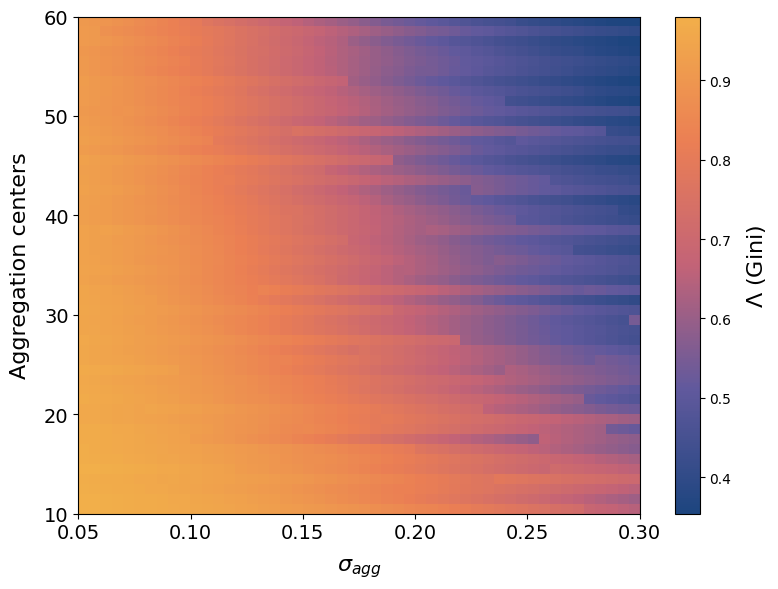

In [36]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

gini_data = np.loadtxt(gini3dfile, skiprows=1)

number_of_centers = np.unique(gini_data[:, 0])
base_sigmas = np.unique(gini_data[:, 1])
Gini_values = gini_data[:, 2]


Gini_map = np.array(Gini_values).reshape(len(number_of_centers), len(base_sigmas))

plt.figure(figsize=(8,6))

im = plt.imshow(
    Gini_map,
    origin='lower',
    aspect='auto',
    extent=[base_sigmas[0], base_sigmas[-1], number_of_centers[0], number_of_centers[-1]],
    cmap=sunset2,
    # interpolation='bicubic'
)

plt.xlabel(r'$\sigma_{agg}$', fontsize=16, labelpad = 10)
plt.ylabel(r'Aggregation centers', fontsize=16, labelpad  = 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Lambda$' + ' (Gini)', fontsize=16, labelpad = 10)

plt.tight_layout()
plt.show()

# -- 3D DYNAMICS --

In [ ]:
import numpy as np
import subprocess
import os
import matplotlib.pyplot as plt 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

# -------- PARAMETERS --------

subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.5 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.7 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 12 # Number of centers for the aggregation of neurons
base_sigma = 0.15 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}


alphas = [0.2]
# alphas = np.arange(0.0, 1.01, 0.01)

filename_params = fcn.run_3D_tune_positions(parameters3D)
path = fcn.create_network3D(parameters3D, alphas)[0]

# -------- USO --------

A = fcn.load_A(path)
C, k, E = fcn.connectivity_from_A(A)

print("Shape:", A.shape)
print('k = ', k)

# Visualización
fcn.neuron_map_adj3D(filename_params, path, parameters3D)

# -------- Pesos --------

N = A.shape[0]

Ne = int(N*0.8)
Ni = int(N*0.2)
N = Ne + Ni

SIM_TIME = 1000

# 2) Izhikevich parameters (con variabilidad)
re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

MAX_EXC_WEIGTH = 2.5
MAX_INH_WEIGTH = 0.5

W = np.hstack([
    MAX_EXC_WEIGTH*np.random.rand(N, Ne),
    -MAX_INH_WEIGTH*np.random.rand(N, Ni)
])

S = A * W
NOISE_MAX = 3

In [ ]:
v = -65*np.ones((N, 1))
u = b * v

firings_t3D = []
firings_i3D = []
    
for t in range(1, SIM_TIME+1):
    I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

    fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

    if fired.size > 0:
        firings_t3D.append(np.full(fired.shape, t, dtype=int))
        firings_i3D.append(fired.copy())

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        # I = I + sum(S(:, fired), 2)
        # En numpy: sumamos columnas "fired" y nos queda vector Nx1
        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    # Integración (paso 0.5 ms x2)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
    u = u + a*(b*v - u)

# Convertir lista de arrays a arrays.
#  planos
if len(firings_t3D) > 0:
    firings_t3D = np.concatenate(firings_t3D)
    firings_i3D = np.concatenate(firings_i3D) + 1  # +1 si quieres neuronas 1..N como en MATLAB
else:
    firings_t3D = np.array([], dtype=int)
    firings_i3D = np.array([], dtype=int)

print("Total spikes:", len(firings_t3D))

In [ ]:
from pypalettes import load_cmap
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

plt.figure(figsize=(6, 5))
plt.scatter(firings_t3D, firings_i3D, s=7, color=sunset2(0.1))
plt.xlabel('Time (ms)', fontsize=16)
plt.ylabel('Neuron', fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(200, 300)
plt.show()

In [ ]:
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks


W = 30  # ms

GNA, active_neurons_count = fcn.compute_GNA_from_raster(
    firings_t=firings_t3D,
    firings_i=firings_i3D,
    N=N,
    SIM_TIME=SIM_TIME,
    W=W,
    indices_are_1_based=True   # en tu código hiciste +1 al final
)

peaks, properties = find_peaks(
    GNA,
    height=10,      # altura mínima del pico en %
    distance=20    # separación mínima entre picos (ms)
)

peak_heights = properties["peak_heights"]
mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0

print("Número de picos detectados:", len(peaks))
print("Alturas de los picos (%):", peak_heights)
print("Altura media de los picos (%):", mean_peak_height)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, SIM_TIME + 1), GNA, lw=1.5, color=sunset2(0.1))
plt.scatter(peaks + 1, GNA[peaks], s=35, color="red", zorder=3)

plt.xlabel("Tiempo (ms)", fontsize=16)
plt.ylabel(f"% neuronas activas\n(W =  {W} ms)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
# plt.xlim(0, 2000)
plt.show()

## -- 3D GNA map --

In [ ]:
import subprocess
import numpy as np
import os

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "3D_tune_positions.c",
    "3D_functions.c",
    "-o",
    "3D_tune_positions.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 15
base_sigmas = np.linspace(0.05, 0.30, 50)

# Handle both a single int and an iterable of centers
n_centers_iter = np.atleast_1d(number_of_centers).astype(int)


for base_sigma in base_sigmas:
    for nc in n_centers_iter:
        parameters3D["n_centers"] = nc
        parameters3D["base_sigma"] = base_sigma

        filename = fcn.run_3D_tune_positions(parameters3D, show_prints=False)
        print(f"Configuration created for n_centers={nc}, base_sigma={base_sigma:.4f}", end="\r")

filenames_params = [
    f"3D_initial_configurations/3D_neurons_params_agg_nc{nc}_s{s:.4f}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}.txt"
    for nc in n_centers_iter
    for s in base_sigmas
]
#Check if files exist
for filename in filenames_params:
    if not os.path.isfile(filename):
        print(f"File not found: {filename}")

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "3D_create_network.c",
    "3D_functions.c",
    "-o",
    "3D_create_network.exe",
    "-lm"
])

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sgima_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (r

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters3D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sgima_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

number_of_centers = 15
parameters3D["n_centers"] = number_of_centers
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))
print(base_sigmas)

alphas = [0.2]

for base_sigma in base_sigmas:
    parameters3D["base_sigma"] = base_sigma
    filename = fcn.create_network3D(parameters3D, alphas, show_prints=False)[0]
    print(filename)
    print(f"Created network for n_centers={number_of_centers}, {parameters3D['base_sigma']:.4f}", end="\r")

In [ ]:
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
from scipy.signal import find_peaks

L = 3.0 # Length of the square domain (mm)
rho = 250 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 0.5 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_pol = 0.1 # Standard deviation of the polar angle (radians)
sigma_azi = 0.1 # Standard deviation of the azimuthal angle (radians)

agg = 1 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.1 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, RBC: Reflective Boundary Conditions)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_pol": sigma_pol,
    "sigma_azi": sigma_azi,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

nc = 15
parameters3D["n_centers"] = nc
base_sigmas = np.linspace(0.05, 0.30, 50)   
print('Length of base_sigmas:', len(base_sigmas))

MAX_EXC_WEIGTH = np.linspace(2, 6, len(base_sigmas))  # Puedes ajustar esto según tus necesidades
print('Length of MAX_EXC_WEIGTH:', len(MAX_EXC_WEIGTH))
MAX_INH_WEIGTH = 0.5

alpha = 0.2

output_filename = f'maps_results/3D_colormap_Gini_Exc_GNA_nc{nc}_L{L:.1f}_rho{rho:.0f}_l{l_mean:.2f}_d{d_mean:.2f}_a{alpha:.3f}.txt'
with open(output_filename, 'w') as f:
     f.write("Gini\tMAX_EXC_WEIGTH\tmean_peaks_height\tstd_peaks_height\n")

i = 0
for base_sigma in base_sigmas:
    parameters3D["base_sigma"] = base_sigma
    path_params = f"3D_initial_configurations/3D_neurons_params_agg_nc{parameters3D['n_centers']}_s{parameters3D['base_sigma']:.4f}_L{parameters3D['L']:.1f}_rho{parameters3D['rho']:.0f}_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}.txt"
    X, Y, _, _, _ = fcn.load_neuron_params(path_params)
    Gini = fcn.Gini_coefficient(X, Y, n_grid = 20, xmin = -parameters3D['L']/2, xmax = parameters3D['L']/2, ymin = -parameters3D['L']/2, ymax = parameters3D['L']/2)
    path_adj = f"3D_created_networks/3D_adjacency_matrix_agg_nc{parameters3D['n_centers']}_s{parameters3D['base_sigma']:.4f}_L{parameters3D['L']:.1f}_rho{parameters3D['rho']:.0f}_l{parameters3D['l_mean']:.2f}_d{parameters3D['d_mean']:.2f}_a{alpha:.3f}.txt"
    A = fcn.load_A(path_adj)
    N = A.shape[0]

    Ne = int(N*0.8)
    Ni = int(N*0.2)
    N = Ne + Ni

    SIM_TIME = 5000

    # 2) Izhikevich parameters (con variabilidad)
    re = np.random.rand(Ne, 1)
    ri = np.random.rand(Ni, 1)

    a = np.vstack([0.02*np.ones((Ne,1)), 0.02 + 0.08*ri])
    b = np.vstack([0.2*np.ones((Ne,1)),  0.25 - 0.05*ri])
    c = np.vstack([-65 + 15*(re**2),     -65*np.ones((Ni,1))])
    d = np.vstack([8 - 6*(re**2),         2*np.ones((Ni,1))])

    for max_exc in MAX_EXC_WEIGTH:

        W = np.hstack([
            max_exc*np.random.rand(N, Ne),
            -MAX_INH_WEIGTH*np.random.rand(N, Ni)
        ])

        S = A * W
        NOISE_MAX = 3

        v = -65*np.ones((N, 1))
        u = b * v

        firings_t = [] # tiempos de disparo
        firings_i = [] # índices de neuronas que disparan (0..N-1)

        for t in range(1, SIM_TIME+1):
            I = np.vstack([NOISE_MAX*np.random.randn(Ne,1), 2*np.random.randn(Ni,1)])

            fired = np.where(v[:,0] >= 30)[0]  # índices (0..N-1)

            if fired.size > 0:
                firings_t.append(np.full(fired.shape, t, dtype=int))
                firings_i.append(fired.copy())

                v[fired] = c[fired]
                u[fired] = u[fired] + d[fired]

                # I = I + sum(S(:, fired), 2)
                # En numpy: sumamos columnas "fired" y nos queda vector Nx1
                I = I + np.sum(S[:, fired], axis=1, keepdims=True)

            # Integración (paso 0.5 ms x2)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            v = v + 0.5*(0.04*v*v + 5*v + 140 - u + I)
            u = u + a*(b*v - u)

        # Convertir lista de arrays a arrays.
        #  planos
        if len(firings_t) > 0:
            firings_t = np.concatenate(firings_t)
            firings_i = np.concatenate(firings_i) + 1  # +1 si quieres neuronas 1..N como en MATLAB
        else:
            firings_t = np.array([], dtype=int)
            firings_i = np.array([], dtype=int)
        
        print(f"Simulated network for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, Gini={Gini:.4f}, total spikes={len(firings_t)}")

        GNA, active_neurons_count = fcn.compute_GNA_from_raster(
            firings_t=firings_t,
            firings_i=firings_i,
            N=N,
            SIM_TIME=SIM_TIME,
            W=25,
            indices_are_1_based=True
        )
        peaks, properties = find_peaks(
            GNA,
            height=0.1,      # altura mínima del pico en %
            distance=20    # separación mínima entre picos (ms)
        )
        peak_heights = properties["peak_heights"]
        mean_peak_height = np.mean(peak_heights) if len(peak_heights) > 0 else 0.0
        print(f"Detected {len(peaks)} peaks in GNA for base_sigma={base_sigma:.4f}, max_exc={max_exc:.2f}, mean_peak_height={mean_peak_height:.4f}%")
        std_peak_height = np.std(peak_heights) if len(peak_heights) > 0 else 0.0

        with open(output_filename, 'a') as f:
            f.write(f"{Gini}\t{max_exc}\t{mean_peak_height}\t{std_peak_height}\n")
        
    i += 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el txt
df = pd.read_csv("maps_results/3D_colormap_Gini_Exc_GNA_nc15_L3.0_rho250_l0.50_d0.15_a0.200.txt", delim_whitespace=True)

# Por si acaso, revisa nombres de columnas
print(df.columns)

# Crear tabla tipo matriz
heatmap_data = df.pivot(
    index="MAX_EXC_WEIGTH",
    columns="Gini",
    values="mean_peaks_height"
)

# Dibujar mapa de calor
plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap_data,
    origin="lower",
    aspect="auto",
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        heatmap_data.index.min(),
        heatmap_data.index.max()
    ]
)

plt.xlabel("Gini")
plt.ylabel("MAX_EXC_WEIGTH")
cbar = plt.colorbar(im)
cbar.set_label("mean_peaks_height")

plt.tight_layout()
plt.show()